# Results

# Viewing Results

In [91]:
import json

def load_probability_model(path):
    with open(path, "r", encoding="utf-8") as f:
        model = json.load(f)
    return model

## Perplexity

Metric that measures the uncertainty of a model's predictions. Specifically, in language models, it quantifies how well the model predicts the next word in a sequence. When a model makes a prediction, it assigns probabilities to possible next words.

Let $w_1, w_2, \dots, w_T$ be a sequence of words in the test set.
The perplexity of an $n$-gram language model is defined as:

$$
\text{Perplexity}
= \exp\left(
-\frac{1}{T}
\sum_{t=1}^{T}
\log P\!\left(
w_t \mid w_{t-(n-1)}, \dots, w_{t-1}
\right)
\right)
$$

GeeksforGeeks. (2025, July 23). Perplexity for LLM evaluation. https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/ 

**Where:**

- $T$ is the total number of tokens (words) in the sentence.

- $w_t$ denotes the word at position $t$ in the sentence.

- $n$ is the order of the N-gram model (e.g., $n = 1$ for a unigram model, $n = 2$ for a bigram model).

- $(w_{t-n+1}, \ldots, w_{t-1})$ represents the $(n-1)$-word context preceding the word $w_t$.

- $P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$ is the conditional probability assigned by the N-gram model to the word $w_t$ given its preceding context.

- $\sum_{t=1}^{T}$ indicates that the log-probabilities are summed over all word positions in the sentence.

- $\log(\cdot)$ is used to convert the product of probabilities into a sum, which improves numerical stability and interpretability.


In [120]:
import json
from math import log, exp 
import pandas as pd

# Function to compute the perplexity of an n-gram model on a test dataset where n is the order of the n-gram model, test_csv is the path to the CSV file containing the test n-grams, prob_dicts is a dictionary of probability models for different n values, and epsilon is a small value to avoid log(0)

def compute_perplexity(test_csv, prob_dicts, n, sample_frac, epsilon=1e-12):
    df = pd.read_csv(test_csv)
    log_prob_sum = 0.0
    T = 0

    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, replace=False, random_state=None) # fraction of data to sample, the sample is different each time as random_state is None

    model = prob_dicts[n]

    for ngram_str in df["N-gram"]:
        ngram = eval(ngram_str)  # ['w1','w2',...]
        target = ngram[-1]

        if n == 1:
            context = "()"
        else:
            context = str(tuple(ngram[:-1]))

        prob = model.get(context, {}).get(target, epsilon) # if the model assigns zero probability, pretend it is very small instead

        log_prob_sum += log(prob)
        T += 1

    return exp(-log_prob_sum / T)

In [121]:
import numpy as np

modeltype = {"word", "character"}
category = "all"  # "business", "entertainment", "politics", "sport", "tech", "all"

N = [1, 2, 3, 4, 5]
num_runs = 10
sample_frac = 0.8  # fixed size, random subsample each run

# Store results as: runs × n
perplexities_word = np.zeros((num_runs, len(N)))
perplexities_char = np.zeros((num_runs, len(N)))

for run in range(num_runs):
    prob_dicts_word = {}
    prob_dicts_char = {}

    for mt in modeltype:
        for i, n in enumerate(N):
            test_file = f"./../Dataset_NGrams/bbc_{mt}_{n}grams_test.csv"
            path = f"./../Probability_NGrams/{mt}_{n}grams_{category}_probability.json"

            if mt == "word":
                prob_dicts_word[n] = load_probability_model(path)
                ppl_word = compute_perplexity(
                    test_file,
                    prob_dicts_word,
                    n,
                    sample_frac=sample_frac
                )
                perplexities_word[run, i] = ppl_word

            else:  # character
                prob_dicts_char[n] = load_probability_model(path)
                ppl_char = compute_perplexity(
                    test_file,
                    prob_dicts_char,
                    n,
                    sample_frac=sample_frac
                )
                perplexities_char[run, i] = ppl_char

# Sample Runs & Averages

To obtain robust perplexity estimates, evaluation was repeated 10 times using random subsampling of 80% of the test n-grams. Final results are reported as the mean perplexity across runs, with standard deviation indicating variability.

In [ ]:
avg_word = perplexities_word.mean(axis=0) # average over runs, method from numpy
std_word = perplexities_word.std(axis=0) # standard deviation over runs, method from numpy

avg_char = perplexities_char.mean(axis=0)
std_char = perplexities_char.std(axis=0)

print("Average perplexities for word N-grams:", avg_word)
print("Average perplexities for character N-grams:", avg_char)

Average perplexities for word N-grams: [1.77992476e+03 1.15368123e+04 4.31031334e+06 1.59412739e+08
 5.42492971e+08]
Average perplexities for character N-grams: [22.36301635 12.2216307   7.67619008  5.37172395  5.47094552]


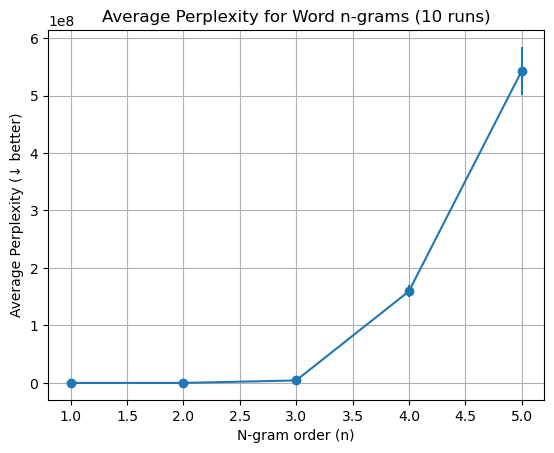

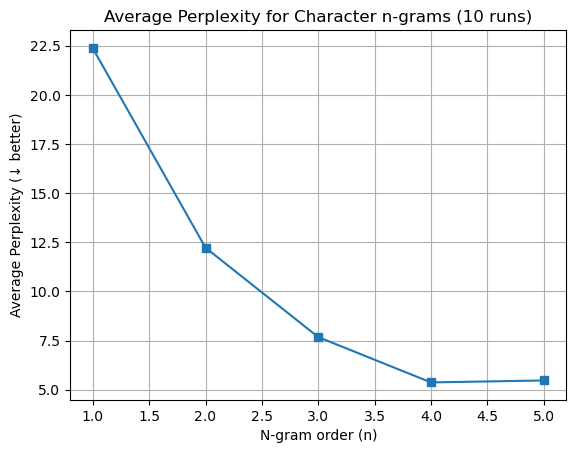

In [129]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(N, avg_word, yerr=std_word, marker='o')
plt.xlabel("N-gram order (n)")
plt.ylabel("Average Perplexity (↓ better)")
plt.title("Average Perplexity for Word n-grams (10 runs)")
plt.grid(True)
plt.show()

plt.figure()
plt.errorbar(N, avg_char, yerr=std_char, marker='s')
plt.xlabel("N-gram order (n)")
plt.ylabel("Average Perplexity (↓ better)")
plt.title("Average Perplexity for Character n-grams (10 runs)")
plt.grid(True)
plt.show()

As the N-gram order increases, perplexity rises sharply. This behavior is expected due to data sparsity: higher-order N-gram models rely on increasingly specific contexts, many of which do not appear in the training data. As a result, the model assigns very low probabilities to test sequences, leading to large perplexity values. Without smoothing or backoff techniques, higher-order models tend to generalize poorly to unseen data despite being more expressive.

## N-gram Accuracy

For each N-gram order, we run the model on testing sentences and measure how often the generated continuation matches the true continuation in the test set. Through this measurement we try to answer: "Does the model’s predicted next word match the actual next word in the dataset?"

$$
\text{Accuracy}_n
=
\frac{
\text{Number of correct next-word predictions}
}{
\text{Total number of predictions}
}
$$

In [ ]:
# Function to evaluate next-word prediction accuracy of an n-gram model where prob_model is the probability model, test_sentence is the tokenized reference sentence, and n is the n-gram order

def evaluate_next_word_accuracy(prob_model, test_sentence, n):

    results = []
    correct = 0
    total = 0

    for i in range(len(test_sentence) - n + 1):
        context_words = test_sentence[i:i + n - 1]
        true_next_word = test_sentence[i + n - 1]

        context = str(tuple(context_words)) if n > 1 else "()"

        if context not in prob_model:
            continue  # model cannot predict for this context

        # choose most probable next word
        predicted_word = max(
            prob_model[context],
            key=prob_model[context].get
        )

        is_correct = (predicted_word == true_next_word)

        results.append(
            (context_words, true_next_word, predicted_word, is_correct)
        )

        correct += int(is_correct)
        total += 1

    accuracy = correct / total if total > 0 else 0.0
    return accuracy, results

In [96]:
#Function to print detailed evaluation results of the n-gram model where results is the list of evaluation tuples and n is the n-gram order

def print_evaluation(results, n, output_path=None):
    lines = []

    header = f"\nEvaluating {n}-gram model\n" + "=" * 50
    print(header)
    lines.append(header)

    for context, true_word, predicted_word, is_correct in results:
        context_str = " ".join(context) if context else "<START>"
        status = "✓" if is_correct else "X"

        block = (
            f"Context: [{context_str}]\n"
            f"True next word: {true_word}\n"
            f"Predicted next word: {predicted_word}\n"
            f"Correct: {status}\n"
            + "-" * 50
        )

        print(block)
        lines.append(block)

    if output_path:
        with open(output_path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

In [ ]:
import pandas as pd
from ast import literal_eval

# Function to load a test sentence from a CSV file where csv_path is the path to the CSV file and n is the n-gram order

def load_test_sentence(csv_path, sample_frac):
    df = pd.read_csv(csv_path)

    df_sample = df.sample(frac=sample_frac, random_state=None).reset_index(drop=True)

    first_ngram = literal_eval(df_sample.iloc[0]["N-gram"])
    sentence = list(first_ngram)

    for i in range(1, len(df_sample)):
        ngram = literal_eval(df_sample.iloc[i]["N-gram"])
        sentence.append(ngram[-1])

    return sentence


In [133]:
test_sentence = load_test_sentence("./../Dataset_NGrams/bbc_word_5grams_test.csv", 0.8)

test_sentence[:15]

['<s>',
 'Malaysia',
 'lifts',
 'Islamic',
 'bank',
 'limit',
 'Malaysias',
 'central',
 'bank',
 'is',
 'to',
 'relax',
 'restrictions',
 'on',
 'foreign']

In [135]:
import numpy as np

modeltypes = ["word", "character"]
N = [1, 2, 3, 4, 5]
num_runs = 10

accuracy_word_runs = {}
accuracy_char_runs = {}

for n in N:
    accuracy_word_runs[n] = []
    accuracy_char_runs[n] = []

for run in range(num_runs):
    for n in N:

        # WORD model
        word_path = f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv"
        test_sentence_word = load_test_sentence(word_path, 0.7)
        acc_word, _ = evaluate_next_word_accuracy(prob_dicts_word[n], test_sentence_word, n)
        accuracy_word_runs[n].append(acc_word)

        # CHARACTER model
        character_path = f"./../Dataset_NGrams/bbc_character_{n}grams_test.csv"
        test_sentence_char = load_test_sentence(character_path, 0.7)
        acc_char, _ = evaluate_next_word_accuracy(prob_dicts_char[n], test_sentence_char, n)
        accuracy_char_runs[n].append(acc_char)


In [137]:
avg_word_acc = [np.mean(accuracy_word_runs[n]) for n in N]
std_word_acc = [np.std(accuracy_word_runs[n]) for n in N]

avg_char_acc = [np.mean(accuracy_char_runs[n]) for n in N]
std_char_acc = [np.std(accuracy_char_runs[n]) for n in N]

print("Average accuracies for word N-grams:", avg_word_acc)
print("Average accuracies for character N-grams:", avg_char_acc)

print("Average standard deviations for word N-grams:", std_word_acc)
print("Average standard deviations for character N-grams:", std_char_acc)

Average accuracies for word N-grams: [np.float64(0.059034482758620686), np.float64(0.17637130801687764), np.float64(0.2930049964311206), np.float64(0.5317551963048499), np.float64(0.7998266897746966)]
Average accuracies for character N-grams: [np.float64(0.17177023916741718), np.float64(0.2615138165798959), np.float64(0.38133640552995385), np.float64(0.5050180650341228), np.float64(0.590560709963695)]
Average standard deviations for word N-grams: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.1102230246251565e-16)]
Average standard deviations for character N-grams: [np.float64(0.0), np.float64(5.551115123125783e-17), np.float64(5.551115123125783e-17), np.float64(0.0), np.float64(0.0)]


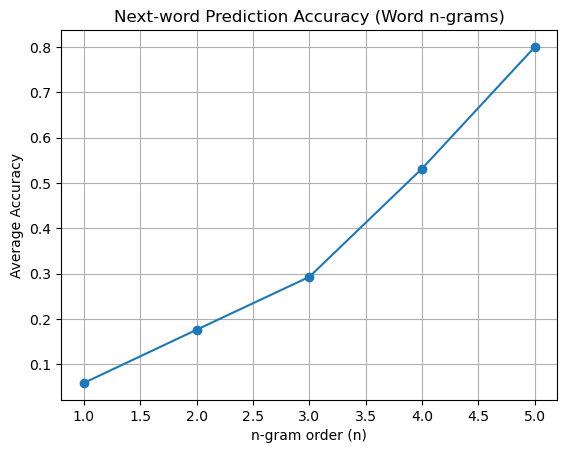

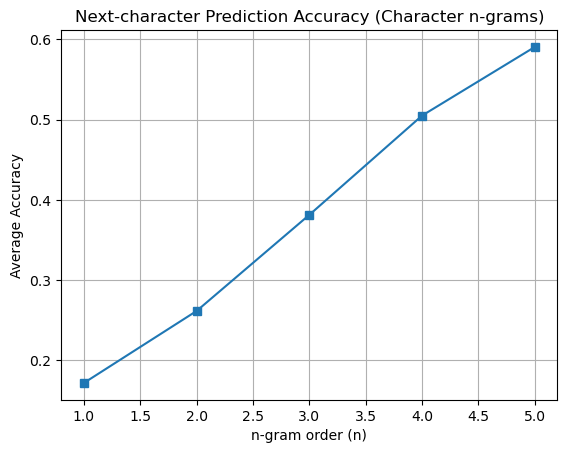

In [139]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(N, avg_word_acc, yerr=std_word_acc, marker='o')
plt.xlabel("n-gram order (n)")
plt.ylabel("Average Accuracy")
plt.title("Next-word Prediction Accuracy (Word n-grams)")
plt.grid(True)
plt.show()

plt.figure()
plt.errorbar(N, avg_char_acc, yerr=std_char_acc, marker='s')
plt.xlabel("n-gram order (n)")
plt.ylabel("Average Accuracy")
plt.title("Next-character Prediction Accuracy (Character n-grams)")
plt.grid(True)
plt.show()

Perplexity evaluates how well an N-gram model predicts the test data, while N-gram overlap measures how closely generated sequences resemble the empirical N-grams in the dataset. Lower perplexity indicates better generalization, whereas higher overlap reflects closer adherence to observed linguistic patterns.